# Sweeper-mode


Starting Grid Search: 24 combinations...
---------------------------------------------------------------------------
Regs  | Order | Reps  | EM_Iter | AIC        | BIC        | Status
---------------------------------------------------------------------------
2     | 1     | 10    | 20      | 2035.70    | 2076.41    | Success
2     | 1     | 10    | 50      | 2035.70    | 2076.41    | Success
2     | 1     | 30    | 20      | 2035.70    | 2076.41    | Success
2     | 1     | 30    | 50      | 2035.70    | 2076.41    | Success
2     | 2     | 10    | 20      | 2064.97    | 2115.85    | Success
2     | 2     | 10    | 50      | 2064.97    | 2115.85    | Success
2     | 2     | 30    | 20      | 2064.97    | 2115.85    | Success
2     | 2     | 30    | 50      | 2064.97    | 2115.85    | Success
2     | 3     | 10    | 20      | 2035.57    | 2096.61    | Success
2     | 3     | 10    | 50      | 2042.41    | 2103.45    | Success
2     | 3     | 30    | 20      | 2035.57    | 2096.61    |

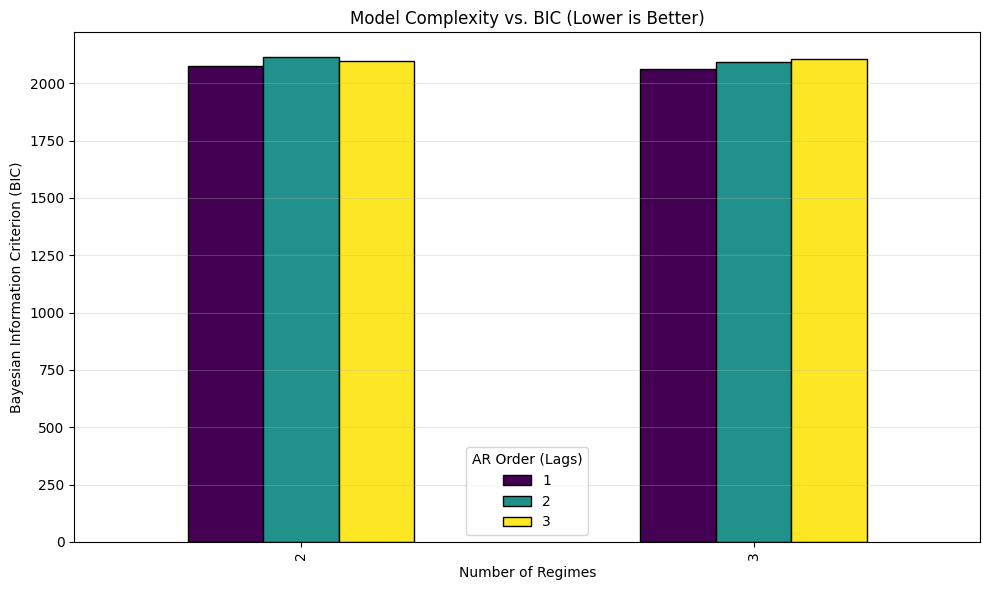

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
import itertools
import warnings

warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1. Fetch Data & Build Rolling Spread
# ------------------------------------------------------------
print("Downloading Data and Building Rolling Spread...")
xom = yf.download("XOM", start="2018-01-01", end="2023-01-01", progress=False)
cvx = yf.download("CVX", start="2018-01-01", end="2023-01-01", progress=False)
col = 'Adj Close' if 'Adj Close' in xom.columns else 'Close'

data = pd.concat([xom[col], cvx[col]], axis=1)
data.columns = ['XOM', 'CVX']
data = data.dropna()

window = 60
spread_series = pd.Series(index=data.index, dtype=float)
for i in range(window, len(data)):
    y_hist = data['XOM'].iloc[i-window:i]
    x_hist = sm.add_constant(data['CVX'].iloc[i-window:i])
    ols_model = sm.OLS(y_hist, x_hist).fit()
    current_x = np.array([1.0, data['CVX'].iloc[i]])
    spread_series.iloc[i] = data['XOM'].iloc[i] - np.dot(current_x, ols_model.params)

spread = spread_series.dropna()

# ------------------------------------------------------------
# 2. Define the Hyperparameter Sweep Grid
# ------------------------------------------------------------
# WARNING: Markov models take a long time to fit. 
# This grid has 2 * 3 * 2 * 2 = 24 combinations. 
regimes_list = [2, 3]
orders_list = [1, 2, 3]
search_reps_list = [10, 30]
em_iters_list = [20, 50]

grid = list(itertools.product(regimes_list, orders_list, search_reps_list, em_iters_list))
results = []

print(f"\nStarting Grid Search: {len(grid)} combinations...")
print("-" * 75)
print(f"{'Regs':<5} | {'Order':<5} | {'Reps':<5} | {'EM_Iter':<7} | {'AIC':<10} | {'BIC':<10} | {'Status'}")
print("-" * 75)

for (k, order, reps, em) in grid:
    try:
        model = MarkovAutoregression(
            spread, k_regimes=k, order=order, trend="c", 
            switching_ar=True, switching_trend=True, switching_variance=True
        )
        res = model.fit(search_reps=reps, em_iter=em, disp=False)
        
        aic = res.aic
        bic = res.bic
        status = "Success"
        
        results.append({
            'Regimes': k, 'Order': order, 
            'Search_Reps': reps, 'EM_Iter': em, 
            'AIC': aic, 'BIC': bic
        })
        
    except Exception as e:
        aic, bic = np.nan, np.nan
        status = "Failed"
        
    print(f"{k:<5} | {order:<5} | {reps:<5} | {em:<7} | {aic:<10.2f} | {bic:<10.2f} | {status}")

# ------------------------------------------------------------
# 3. Analyze and Plot Results
# ------------------------------------------------------------
df_res = pd.DataFrame(results).dropna()

# Find the absolute best model according to BIC (Heavily penalizes overfitting)
best_model = df_res.loc[df_res['BIC'].idxmin()]

print("\n" + "="*50)
print("🏆 BEST ARCHITECTURE (Based on lowest BIC) 🏆")
print("="*50)
print(best_model.to_string())

# Plotting the impact of Lags (Order) and Regimes on BIC
fig, ax = plt.subplots(figsize=(10, 6))

# Group by Architecture (ignoring Reps/Iters by taking the minimum BIC achieved for that architecture)
arch_grouped = df_res.groupby(['Regimes', 'Order'])['BIC'].min().unstack()

arch_grouped.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='k')
ax.set_title('Model Complexity vs. BIC (Lower is Better)')
ax.set_ylabel('Bayesian Information Criterion (BIC)')
ax.set_xlabel('Number of Regimes')
ax.legend(title='AR Order (Lags)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()